In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from collections import Counter
import json

In [9]:
SAMPLE_DIR = Path("samples/v3_1000/res_20250627_n100")

queries_labeled_df = pd.read_csv(SAMPLE_DIR / "_queries_labeled.csv")
responses_df = pd.read_csv(SAMPLE_DIR / "_responses.csv")
urls_pool_df = pd.read_csv(SAMPLE_DIR / "_urls_pool.csv")
classified_urls_df = pd.read_csv(SAMPLE_DIR / "_classified_urls.csv")

In [ ]:
print("Number of queries:", len(queries_labeled_df))
print("Number of AI Overviews triggered:", (queries_labeled_df["triggered_ai_overview"] == 'y').sum())
print("Number of pooled documents:", len(urls_pool_df))
print("Number of classified documents:", len(classified_urls_df))

Number of queries: 1000
Number of AI Overviews triggered: 409
Number of pooled documents: 35932
Number of classified documents: 18791


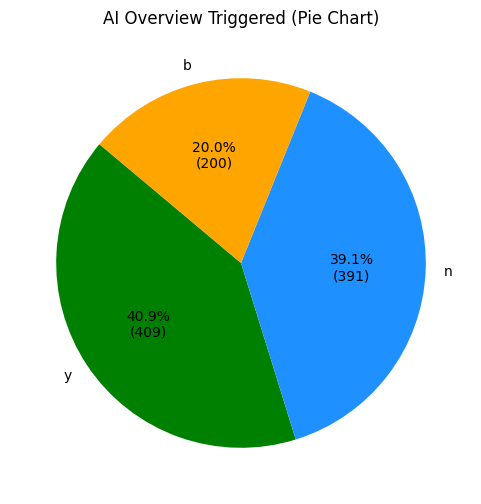

In [6]:
# Distribution of returned AI overview results (Y/N/B) for all queries

counts = queries_labeled_df['triggered_ai_overview'].value_counts()

# Pie chart
plt.figure(figsize=(6, 6))
plt.pie(
    counts,
    labels=["y", "n", "b"],
    autopct=lambda pct: f'{pct:.1f}%\n({int(round(pct/100.*sum(counts)))})',
    startangle=140,
    colors=["green", "dodgerblue", "orange"]
)
plt.title("AI Overview Triggered (Pie Chart)")
plt.show()

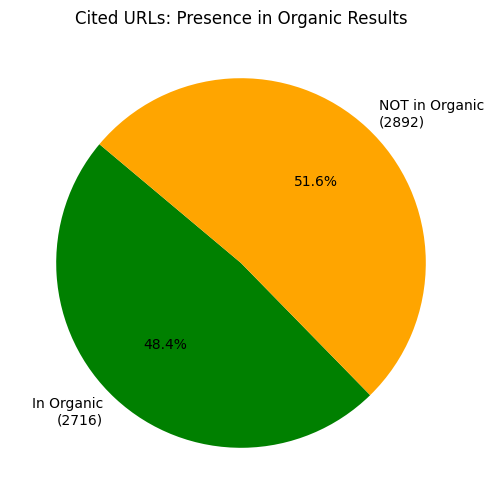

In [24]:
in_organic = 0
not_in_organic = 0

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = set(json.loads(row["organic_results"]))
    except Exception:
        continue

    for url in refs:
        if url in organic:
            in_organic += 1
        else:
            not_in_organic += 1

total = in_organic + not_in_organic
values = [in_organic, not_in_organic]
labels = [
    f"In Organic\n({in_organic})",
    f"NOT in Organic\n({not_in_organic})"
]

plt.figure(figsize=(6, 6))
plt.pie(
    values,
    labels=labels,
    autopct=lambda pct: f'{pct:.1f}%',
    colors=["green", "orange"],
    startangle=140
)
plt.title("Cited URLs: Presence in Organic Results")
plt.show()

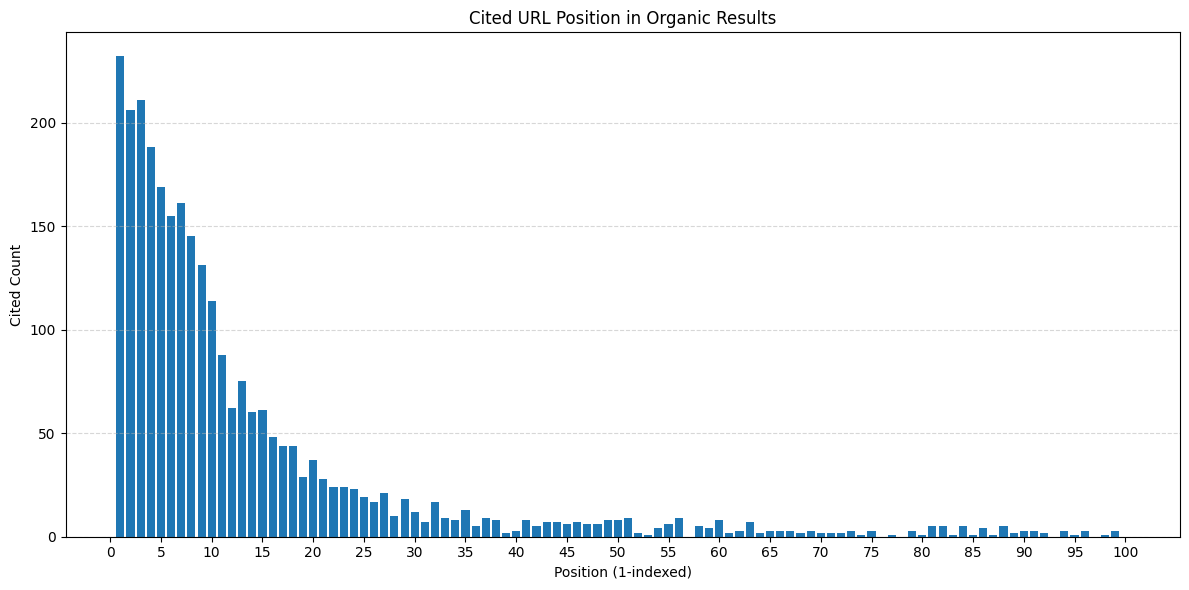

In [16]:
position_counter = Counter()

for _, row in responses_df.iterrows():
    try:
        refs = set(json.loads(row["references"]))
        organic = json.loads(row["organic_results"])
    except Exception:
        continue

    for i, url in enumerate(organic):
        if url in refs:
            position_counter[i + 1] += 1

positions = list(range(1, 101))
counts = [position_counter.get(i, 0) for i in positions]

plt.figure(figsize=(12, 6))
plt.bar(positions, counts)
plt.title("Cited URL Position in Organic Results")
plt.xlabel("Position (1-indexed)")
plt.ylabel("Cited Count")
plt.xticks(range(0, 101, 5))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()